In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from myutils import display_ppm_image,convert_jfif_to_ppm,predict_traffic_sign_all,ppm_to_tensor_tf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from GTSRB_utils import GTSRB_CLASSES, predict_traffic_sign, create_subset_loader, load_ppm_image

In [3]:

from tensorflow.keras.models import load_model
model = load_model("/content/EfficientNetB1.keras")

In [ ]:
def MI_fgsm_single_image(model, image, label, epsilon, iterations, mu):
    """
    Perform MI_FGSM attack on a single image without normalization.

    Args:
        model: Trained model.
        image: Input image of shape (C, H, W), Normalized.
        label: True target mask.
        epsilon (float): Perturbation magnitude.
        iterations: Number of iterations
        mu: decay factor of momentum

    Returns:
        Adversarial example (Normalized).
    """

    model.eval()
    # get step size per itertion
    alpha = epsilon / iterations

    # Initialize adversarial image
    adversarial_image = image.clone().detach().requires_grad_(True)

    # Define the velocity vector
    g = torch.zeros_like(adversarial_image)
    for t in range(iterations):
        model.zero_grad()

        # Forward pass
        prediction = model(adversarial_image.unsqueeze(0))
        # Calculate loss
        loss_fn = nn.BCEWithLogitsLoss()
        loss = loss_fn(prediction.squeeze(0), label.unsqueeze(0))
        # Backpropagate
        loss.backward()

        grad = adversarial_image.grad.data
        grad = grad / torch.abs(grad).sum()  # Apply L1 norm on gradient

        # calculate momentum
        g = mu * g + grad

        # Get the sign of the gradient and update the adversarial image
        adversarial_image = adversarial_image + alpha * torch.sign(g)

        # Project the adversarial image into the epsilon-ball and clip to [0, 1]
        adversarial_image = torch.max(torch.min(adversarial_image, image + epsilon), image - epsilon)
        adversarial_image = torch.clamp(adversarial_image, 0, 1)

        # Detach and re-enable gradient computation
        adversarial_image = adversarial_image.detach().requires_grad_(True)
        print(loss.item())


    return adversarial_image.squeeze(0)

In [18]:
import numpy as np
import tensorflow as tf

def predict_traffic_sign(model, img_input, class_mapping):
    """
    Accepts a tensor (rank 3 or 4), raw image bytes, or a file path.
    """
    # Ensure img_input has a batch dimension (shape: (batch_size, H, W, C))
    if len(img_input.shape) == 3:
        img_input = tf.expand_dims(img_input, axis=0)  # Add batch dimension

    # Get predictions
    prop = model.predict(img_input)
    print("Prediction shape:", prop.shape)

    # Get the predicted class index
    class_id = np.argmax(prop[0])  # prop[0] because we have a batch size of 1
    print("Predicted class:", class_mapping[class_id])

    # Return the one-hot encoded label
    return tf.one_hot(class_id, depth=prop.shape[-1])  # One-hot encode based on number of classes


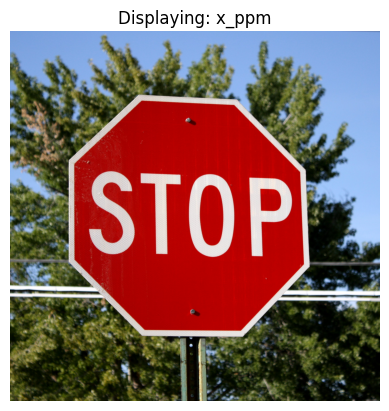

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Predicted class: Stop


In [19]:
 from pickle import load
x_ppm=convert_jfif_to_ppm("/content/Stopsign.jfif","x_ppm")
display_ppm_image("x_ppm")
x=load_ppm_image("x_ppm",target_size=(240, 240))
y=predict_traffic_sign(model,x,GTSRB_CLASSES)



In [21]:
print(y.shape)

(43,)


In [28]:
def mi_fgsm(model, x, y, epsilon=8.0, T=10, mu=1.0):
    """
    MI-FGSM attack for models that take unnormalized inputs in [0, 255].

    Args:
        model: A tf.keras.Model that outputs logits.
        x: Input image tensor (float32) in [0, 255].
        y: Ground-truth label (int or one-hot).
        epsilon: Perturbation bound (L∞ norm), e.g. 8.0 for images in [0, 255].
        T: Number of iterations.
        mu: Momentum decay factor.

    Returns:
        x_star: Adversarial image in [0, 255].
    """
    epsilon = epsilon * 255.0
    x = tf.cast(x, tf.float32)
    x_star = tf.identity(x)
    alpha = epsilon / T
    g = tf.zeros_like(x)

    # Ensure y is an integer before one-hot encoding and reshape it to (1, 43)
    y = tf.cast(y, tf.int32)  # Ensure it's int32
    if len(y.shape) == 1 or y.shape[-1] == 1:
        y = tf.one_hot(y, depth=model.output_shape[-1])

    # Ensure the batch size dimension is (1, 43)
    if len(y.shape) == 2 and y.shape[0] == 43:
        y = tf.reshape(y, (1, 43))  # Reshape to (1, 43) if necessary

    loss_object = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    for _ in range(T):
        with tf.GradientTape() as tape:
            tape.watch(x_star)
            logits = model(x_star)
            loss = loss_object(y, logits)

        grad = tape.gradient(loss, x_star)

        # Normalize gradient by L1 norm
        grad_norm = tf.reduce_sum(tf.abs(grad), axis=list(range(1, len(grad.shape))), keepdims=True)
        grad_norm = tf.maximum(grad_norm, 1e-8)  # avoid division by zero
        normalized_grad = grad / grad_norm

        # Momentum update
        g = mu * g + normalized_grad

        # Update adversarial image
        x_star = x_star + alpha * tf.sign(g)

        # Project perturbation back into epsilon-ball (unnormalized range)
        x_star = tf.clip_by_value(x_star, x - epsilon, x + epsilon)

        # Ensure pixel values are still in valid [0, 255] range
        x_star = tf.clip_by_value(x_star, 0.0, 255.0)

    return x_star


In [44]:
import tensorflow as tf


def mi_fgsm(model, x, y, epsilon=8.0, T=10, mu=1.0):
    """
    MI-FGSM attack for models that take unnormalized inputs in [0, 255].

    Args:
        model: A tf.keras.Model that outputs logits.
        x: Input image tensor (float32) in [0, 255], shape (batch_size, H, W, C).
        y: Ground-truth label (int scalar, int vector, or one-hot),
           with shape (), (batch_size,), (num_classes,), or (batch_size, num_classes).
        epsilon: Perturbation bound (L∞ norm), e.g. 8.0 for images in [0, 255].
        T: Number of iterations.
        mu: Momentum decay factor.

    Returns:
        x_star: Adversarial image tensor in [0, 255], same shape as x.
    """
    # Scale epsilon to pixel range
    epsilon = epsilon * 255.0

    # Cast inputs
    x = tf.cast(x, tf.float32)
    x_star = tf.identity(x)
    batch_size = tf.shape(x)[0]

    # Step size per iteration
    alpha = epsilon / float(T)

    # Initialize momentum buffer
    g = tf.zeros_like(x)

    # Prepare labels
    num_classes = model.output_shape[-1]
    y = tf.cast(y, tf.int32)
    y_shape = y.shape
    # Case 1: scalar label
    if y_shape.ndims == 0:
        y = tf.expand_dims(y, 0)
        y = tf.one_hot(y, depth=num_classes)
    # Case 2: vector
    elif y_shape.ndims == 1:
        # If length equals num_classes, assume one-hot vector
        if y_shape[0] == num_classes:
            y = tf.expand_dims(tf.cast(y, tf.float32), 0)
        else:
            # integer class indices
            y = tf.one_hot(y, depth=num_classes)
    # Case 3: already (batch_size, num_classes)
    elif y_shape.ndims == 2 and y_shape[1] == num_classes:
        y = tf.cast(y, tf.float32)
    else:
        raise ValueError(f"Unsupported label shape: {y_shape}")

    loss_object = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    # Iterative attack
    for _ in range(T):
        with tf.GradientTape() as tape:
            tape.watch(x_star)
            logits = model(x_star)
            loss = loss_object(y, logits)

        # Compute gradient
        grad = tape.gradient(loss, x_star)

        # Normalize by L1 norm
        grad_norm = tf.reduce_sum(
            tf.abs(grad),
            axis=list(range(1, len(grad.shape))),
            keepdims=True
        )
        grad_norm = tf.maximum(grad_norm, 1e-8)
        normalized_grad = grad / grad_norm

        # Momentum update
        g = mu * g + normalized_grad

        # Perturbation step
        x_star = x_star + alpha * tf.sign(g)

        # Project back into epsilon-ball
        x_star = tf.clip_by_value(x_star, x - epsilon, x + epsilon)

        # Clip to valid pixel range
        x_star = tf.clip_by_value(x_star, 0.0, 255.0)

    return x_star


# Usage example remains the same as before


In [46]:

def save_adv_image_as_png(adv_image, path):
    """
    Save adversarial image tensor as a PNG file.
    adv_image: Tensor shape (batch_size, H, W, C) in [0,255]
    path: output file path, e.g. 'adv.png'
    """
    adv_np = adv_image.numpy().astype(np.uint8)[0]
    Image.fromarray(adv_np).save(path)
    print(f"Saved adversarial image as PNG to {path}")


def save_adv_image_as_ppm(adv_image, path):
    """
    Save adversarial image tensor as a PPM (P6) file.
    adv_image: Tensor shape (batch_size, H, W, C) in [0,255]
    path: output file path, e.g. 'adv.ppm'
    """
    adv_np = adv_image.numpy().astype(np.uint8)[0]
    h, w, c = adv_np.shape
    # PPM P6 header
    header = f"P6 {w} {h} 255\n".encode()
    with open(path, 'wb') as f:
        f.write(header)
        f.write(adv_np.tobytes())
    print(f"Saved adversarial image as PPM to {path}")


def save_tensor(adv_image, path):
    """
    Serialize and save the adversarial tensor to a file.
    adv_image: Tensor of any shape
    path: output file path, e.g. 'adv.tensor'
    """
    tensor_str = tf.io.serialize_tensor(adv_image)
    tf.io.write_file(path, tensor_str)
    print(f"Saved adversarial tensor to {path}")

In [57]:
if __name__ == "__main__":
    import numpy as np
    from PIL import Image

    # Assume you have these helper functions defined elsewhere:
    #   load_ppm_image(path) -> tensor shape (1, H, W, C) in [0,255]
    #   predict_traffic_sign(model, img_tensor, class_mapping) -> one-hot label tensor
    # And a dictionary GTSRB_CLASSES mapping class indices to names.

    # Load your pretrained model
    #model = tf.keras.models.load_model('path_to_your_model.h5')

    # Load and preprocess an image
    x = load_ppm_image("/content/x_ppm", target_size=(240, 240))  # shape (1,240,240,3)

    # Get the predicted label as one-hot
    y = predict_traffic_sign(model, x, GTSRB_CLASSES)  # returns tensor shape (1, num_classes)

    # Generate adversarial example
    stop_adv_image = mi_fgsm(model, x, y, epsilon=0.03, T=10, mu=1)

    # Visualize or save the adversarial image
    #adv_np = adv_image.numpy().astype(np.uint8)[0]
   # Image.fromarray(adv_np).save("stopsign_adverserial.png")
    #print("Adversarial image saved as stopsign_adv.png")




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
Prediction shape: (1, 43)
Predicted class: Stop


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


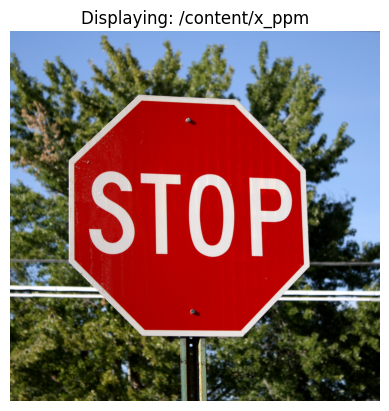

In [62]:
display_ppm_image("/content/x_ppm")

In [63]:
predict_traffic_sign_all(x,model,GTSRB_CLASSES)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0000
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0000
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 1.0000
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0000
Class 17 (No entry): 0.0000
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(14)

In [64]:
save_adv_image_as_ppm(stop_adv_image,"stopsign_adverserial.ppm")

Saved adversarial image as PPM to stopsign_adverserial.ppm


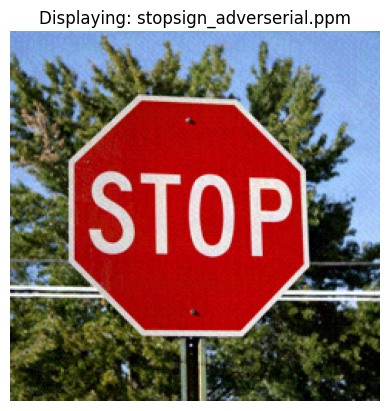

In [67]:
display_ppm_image("stopsign_adverserial.ppm")

In [69]:
 # Generate adversarial example
stop_adv_image_v2 = mi_fgsm(model, x, y, epsilon=0.02, T=10, mu=1)

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


In [70]:
save_adv_image_as_ppm(stop_adv_image_v2,"stopsign_adverserial_v2.ppm")

Saved adversarial image as PPM to stopsign_adverserial_v2.ppm


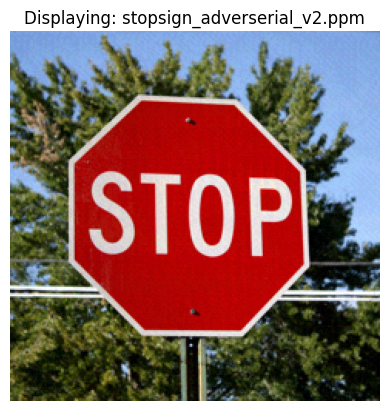

In [71]:
display_ppm_image("stopsign_adverserial_v2.ppm")

In [73]:
predict_traffic_sign_all(stop_adv_image,model,GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0000
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0000
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0000
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0000
Class 17 (No entry): 1.0000
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(17)

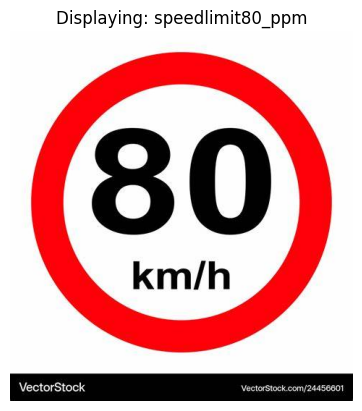

In [74]:
convert_jfif_to_ppm("/content/Limit80v2.jfif","speedlimit80_ppm")
display_ppm_image("speedlimit80_ppm")

In [76]:
second_image=load_ppm_image("speedlimit80_ppm",target_size=(240, 240))


In [78]:
y_80=predict_traffic_sign_all(second_image,model,GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0004
Class 2 (Speed limit 50): 0.0116
Class 3 (Speed limit 60): 0.0001
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.9605
Class 6 (End of speed limit 80): 0.0001
Class 7 (Speed limit 100): 0.0030
Class 8 (Speed limit 120): 0.0070
Class 9 (No passing): 0.0000
Class 10 (No passing for vehicles over 3.5 tons): 0.0029
Class 11 (Right-of-way at next intersection): 0.0022
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0003
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0000
Class 17 (No entry): 0.0062
Class 18 (General caution): 0.0001
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0002
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (T

In [79]:
print(y_80)

5


In [83]:
 # Generate adversarial example
Sign80_adv_image_v1 = mi_fgsm(model, second_image, y_80, epsilon=0.02, T=10, mu=1)
Sign80_adv_image_v2 = mi_fgsm(model, second_image, y_80, epsilon=0.05, T=10, mu=1)
Sign80_adv_image_v3 = mi_fgsm(model, second_image, y_80, epsilon=0.1, T=10, mu=1)

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


In [84]:
save_adv_image_as_ppm(Sign80_adv_image_v1,"Sign80_adv_image_v1.ppm")
save_adv_image_as_ppm(Sign80_adv_image_v2,"Sign80_adv_image_v2.ppm")
save_adv_image_as_ppm(Sign80_adv_image_v3,"Sign80_adv_image_v3.ppm")

Saved adversarial image as PPM to Sign80_adv_image_v1.ppm
Saved adversarial image as PPM to Sign80_adv_image_v2.ppm
Saved adversarial image as PPM to Sign80_adv_image_v3.ppm


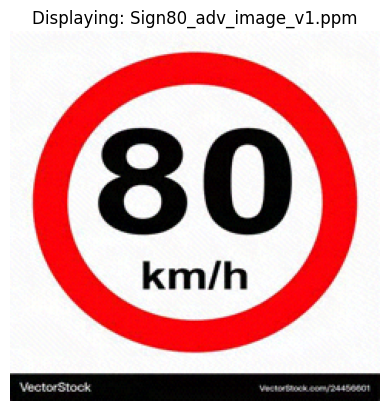

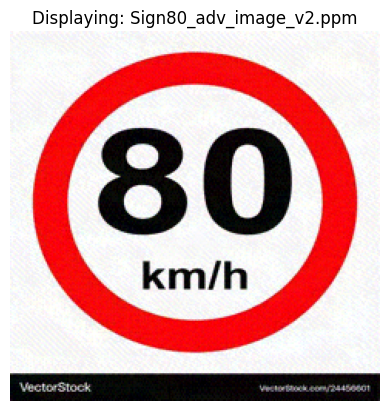

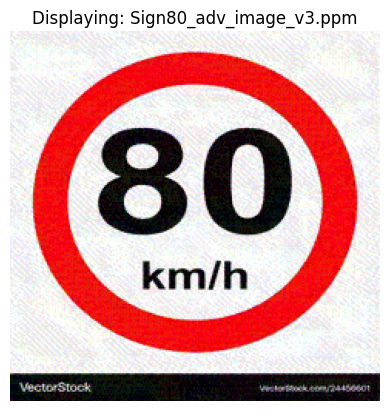

In [85]:
display_ppm_image("Sign80_adv_image_v1.ppm")
display_ppm_image("Sign80_adv_image_v2.ppm")
display_ppm_image("Sign80_adv_image_v3.ppm")


In [86]:
predict_traffic_sign_all(Sign80_adv_image_v1,model,GTSRB_CLASSES)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0257
Class 1 (Speed limit 30): 0.0003
Class 2 (Speed limit 50): 0.0749
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0001
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0001
Class 8 (Speed limit 120): 0.0761
Class 9 (No passing): 0.0002
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0056
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0024
Class 17 (No entry): 0.6786
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0001
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (T

np.int64(17)

In [87]:
predict_traffic_sign_all(Sign80_adv_image_v2,model,GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0039
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0000
Class 8 (Speed limit 120): 0.0089
Class 9 (No passing): 0.0001
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0001
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0006
Class 17 (No entry): 0.9832
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(17)

In [88]:
predict_traffic_sign_all(Sign80_adv_image_v3,model,GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0000
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0000
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0000
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0000
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0000
Class 17 (No entry): 1.0000
Class 18 (General caution): 0.0000
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(17)

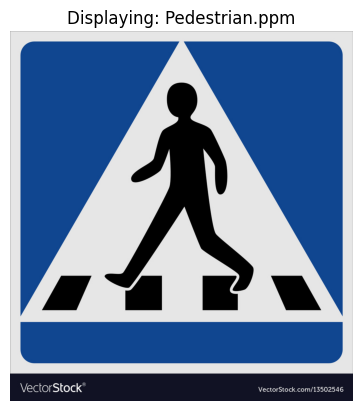

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
Prediction shape: (1, 43)
Predicted class: Road work


In [91]:
convert_jfif_to_ppm("/content/Pedestrian.jfif","Pedestrian.ppm")
display_ppm_image("Pedestrian.ppm")
x_pedestrian=load_ppm_image("Pedestrian.ppm",target_size=(240, 240))
y_pedestrian=predict_traffic_sign(model,x_pedestrian,GTSRB_CLASSES)


In [92]:
Pedestrian_advimage = mi_fgsm(model, x_pedestrian, y_pedestrian, epsilon=0.02, T=10, mu=1)

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


In [93]:
save_adv_image_as_ppm(Pedestrian_advimage,"Pedestrian_advimage.ppm")

Saved adversarial image as PPM to Pedestrian_advimage.ppm


In [94]:
predict_traffic_sign_all(Pedestrian_advimage,model,GTSRB_CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (1, 43)
Class 0 (Speed limit 20): 0.0000
Class 1 (Speed limit 30): 0.0000
Class 2 (Speed limit 50): 0.0000
Class 3 (Speed limit 60): 0.0000
Class 4 (Speed limit 70): 0.0000
Class 5 (Speed limit 80): 0.0000
Class 6 (End of speed limit 80): 0.0000
Class 7 (Speed limit 100): 0.0000
Class 8 (Speed limit 120): 0.0000
Class 9 (No passing): 0.0000
Class 10 (No passing for vehicles over 3.5 tons): 0.0000
Class 11 (Right-of-way at next intersection): 0.0001
Class 12 (Priority road): 0.0000
Class 13 (Yield): 0.0000
Class 14 (Stop): 0.0000
Class 15 (No vehicles): 0.0000
Class 16 (Vehicles over 3.5 tons prohibited): 0.0000
Class 17 (No entry): 0.0008
Class 18 (General caution): 0.9983
Class 19 (Dangerous curve left): 0.0000
Class 20 (Dangerous curve right): 0.0000
Class 21 (Double curve): 0.0000
Class 22 (Bumpy road): 0.0000
Class 23 (Slippery road): 0.0000
Class 24 (Road narrows on the right): 0.0000
Class 25 (Road work): 0.0000
Class 26 (Traf

np.int64(18)

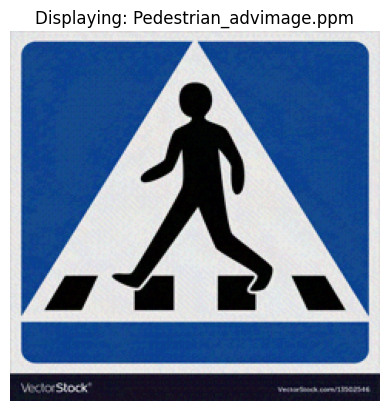

In [95]:
display_ppm_image("Pedestrian_advimage.ppm")

In [96]:
import zipfile
import os

zip_path = "/content/Attack_testdata.zip"  # Replace with your ZIP filename
extract_path = "extracted_data"  # You can name this anything

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [97]:
image_extensions = ('.jpg', '.jpeg', '.png')

image_count = 0
for root, dirs, files in os.walk(extract_path):
    image_count += len([f for f in files if f.lower().endswith(image_extensions)])

print(f"Total number of image samples: {image_count}")


Total number of image samples: 516


In [100]:
import pandas as pd

# Load the CSV file
labels_df = pd.read_csv("/content/extracted_data/Attack_Test.csv")

# Display the first few rows to understand the structure
print(labels_df.head())

# Assuming the CSV has columns like 'filename' and 'label'
# Adjust column names based on the actual CSV structure
image_filenames = labels_df['Path'].values  # e.g., '12617.png'
labels = labels_df['ClassId'].values  # e.g., 0 or 1, or class names


import tensorflow as tf
import numpy as np

# Define image parameters
img_height = 240  # Adjust to match your model's expected input size
img_width = 240
batch_size = 32

# Function to load and preprocess images (using tf operations)
def load_and_preprocess_image(image_path):
    # Read the image file
    img = tf.io.read_file(image_path)  # image_path is already a tensor string
    img = tf.image.decode_png(img, channels=3)  # Assuming RGB images

    # Resize to target size
    img = tf.image.resize(img, [img_height, img_width])

    return img

# Create a dataset from the image filenames and labels
def create_dataset(image_filenames, labels):
    # Convert filenames and labels to tensors
    base_dir = "/content/extracted_data"
    image_paths = [os.path.join(base_dir, fname) for fname in image_filenames]
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Map the load_and_preprocess_image function
    dataset = dataset.map(
        lambda path, label: (load_and_preprocess_image(path), label),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Shuffle, batch, and prefetch
    dataset = dataset.shuffle(buffer_size=len(image_filenames))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Create the dataset
dataset = create_dataset(image_filenames, labels)

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId       Path
0     39      39       6       5      34      34        0  00243.png
1     39      40       5       5      34      35        0  00778.png
2     35      36       5       6      30      31        0  04726.png
3     49      51       6       5      44      46        0  06854.png
4     34      34       6       6      29      29        0  02045.png


In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = []
y_pred = []

for batch_images, batch_labels in dataset:
    preds = model.predict(batch_images)
    pred_classes = tf.argmax(preds, axis=1).numpy()

    y_true.extend(batch_labels.numpy())
    y_pred.extend(pred_classes)

# Evaluate
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=GTSRB_CLASSES.values() if isinstance(GTSRB_CLASSES, dict) else class_mapping))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 47s 47s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Accuracy: 0.9632

Classification Report:
                                              precision    recall  f1-score   support

                              Speed limit 20       1.00      1.00      1.00        12
                              Speed limit 30       1.00      1.00      1.00        12
                              Speed limit 50       1.00 

In [104]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Path to the image directory
new_directory_path = "/content/extracted_data"

# Load image filenames
image_filenames = [file for file in os.listdir(new_directory_path) if file.lower().endswith(".png")]

# Load labels
df = pd.read_csv("/content/extracted_data/Attack_Test.csv")

# Load model
model = tf.keras.models.load_model("/content/EfficientNetB1.keras")

# Image preprocessing parameters
img_height = 240
img_width = 240
batch_size = 32

# MI-FGSM parameters
epsilon = 0.03
T = 10
mu = 1

# Storage for adversarial examples
adv_images = []
adv_labels = []

# Loop through the clean dataset and apply MI-FGSM
for image_path in tqdm(image_filenames, total=len(image_filenames)):
    # Get label
    matching_row = df[df['Path'] == image_path]
    if not matching_row.empty:
        label = matching_row.iloc[0]['ClassId']

        # Load and preprocess image
        full_path = os.path.join(new_directory_path, image_path)
        img_raw = tf.io.read_file(full_path)
        img = tf.image.decode_png(img_raw, channels=3)
        img = tf.image.resize(img, [img_height, img_width])

        img = tf.expand_dims(img, axis=0)  # Shape: (1, H, W, C)
        img = tf.cast(img, tf.float32)
        # Prepare label tensor
        label_tensor = tf.convert_to_tensor([label], dtype=tf.int32)

        # Apply MI-FGSM
        adv_img = mi_fgsm(model, img, label_tensor, epsilon=epsilon, T=T, mu=mu)

        # Store adversarial example
        adv_images.append(adv_img[0].numpy())  # Remove batch dim
        adv_labels.append(label)

# Convert to tensors
adv_images_tensor = tf.convert_to_tensor(adv_images)
adv_labels_tensor = tf.convert_to_tensor(adv_labels)

# Create TF dataset
adv_dataset = tf.data.Dataset.from_tensor_slices((adv_images_tensor, adv_labels_tensor))
adv_dataset = adv_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Evaluate adversarial examples
y_true_adv = []
y_pred_adv = []

for batch_images, batch_labels in adv_dataset:
    preds = model.predict(batch_images)
    pred_classes = tf.argmax(preds, axis=1).numpy()
    y_true_adv.extend(batch_labels.numpy())
    y_pred_adv.extend(pred_classes)

# Report metrics
acc_adv = accuracy_score(y_true_adv, y_pred_adv)
print(f"\nAdversarial Test Accuracy (MI-FGSM): {acc_adv:.4f}")

print("\nClassification Report (MI-FGSM):")
print(classification_report(y_true_adv, y_pred_adv))

print("\nConfusion Matrix (MI-FGSM):")
print(confusion_matrix(y_true_adv, y_pred_adv))


  0%|          | 0/516 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
100%|██████████| 516/516 [2:23:35<00:00, 16.70s/it]


1/1 ━━━━━━━━━━━━━━━━━━━━ 39s 39s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

Adversarial Test Accuracy (MI-FGSM): 0.0271

Classification Report (MI-FGSM):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00        12
    

MI-Fgsm Pre and Post Attack Performance Metrics using epsilon=0.03 and momentum decay factor=1

| Metric                    | Clean Data | Adversarial Data (MI-FGSM) | Drop |
|---------------------------|------------|-----------------------------|------|
| Accuracy                  | 96.32%     | 2.71%                       | 93.61% |
| Macro Avg Precision       | 97%        | 3%                          | 94%    |
| Macro Avg Recall          | 96%        | 3%                          | 93%    |
| Macro Avg F1-score        | 96%        | 2%                          | 94%    |
| Weighted Avg Precision    | 97%        | 3%                          | 94%    |
| Weighted Avg Recall       | 96%        | 3%                          | 93%    |
| Weighted Avg F1-score     | 96%        | 2%                          | 94%    |


In [105]:
from PIL import Image

# Directory to save adversarial examples
save_dir = "/content/mi_fgsm_adversarial_examples"
os.makedirs(save_dir, exist_ok=True)

# Save each adversarial image
for i, adv_img_np in enumerate(adv_images):
    # Use original filename for reference
    original_name = image_filenames[i]
    filename = f"adv_{original_name}"
    save_path = os.path.join(save_dir, filename)

    # Ensure the image is in valid range and uint8 format
    img_to_save = tf.clip_by_value(adv_img_np, 0, 255)
    img_uint8 = tf.cast(img_to_save, tf.uint8).numpy()

    # Save the image
    Image.fromarray(img_uint8).save(save_path)


In [108]:
# Save filenames and labels to a CSV
save_df = pd.DataFrame({
    'Path': [f"adv_{fname}" for fname in image_filenames],
    'ClassId': adv_labels
})
save_df.to_csv("/content/mi_fgsm_adversarial_examples/adv_labels.csv", index=False)


In [110]:
import shutil

shutil.make_archive("/content/adversarial_examples", 'zip', "/content/mi_fgsm_adversarial_examples")


'/content/adversarial_examples.zip'

In [111]:
from google.colab import files

files.download("/content/adversarial_examples.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step


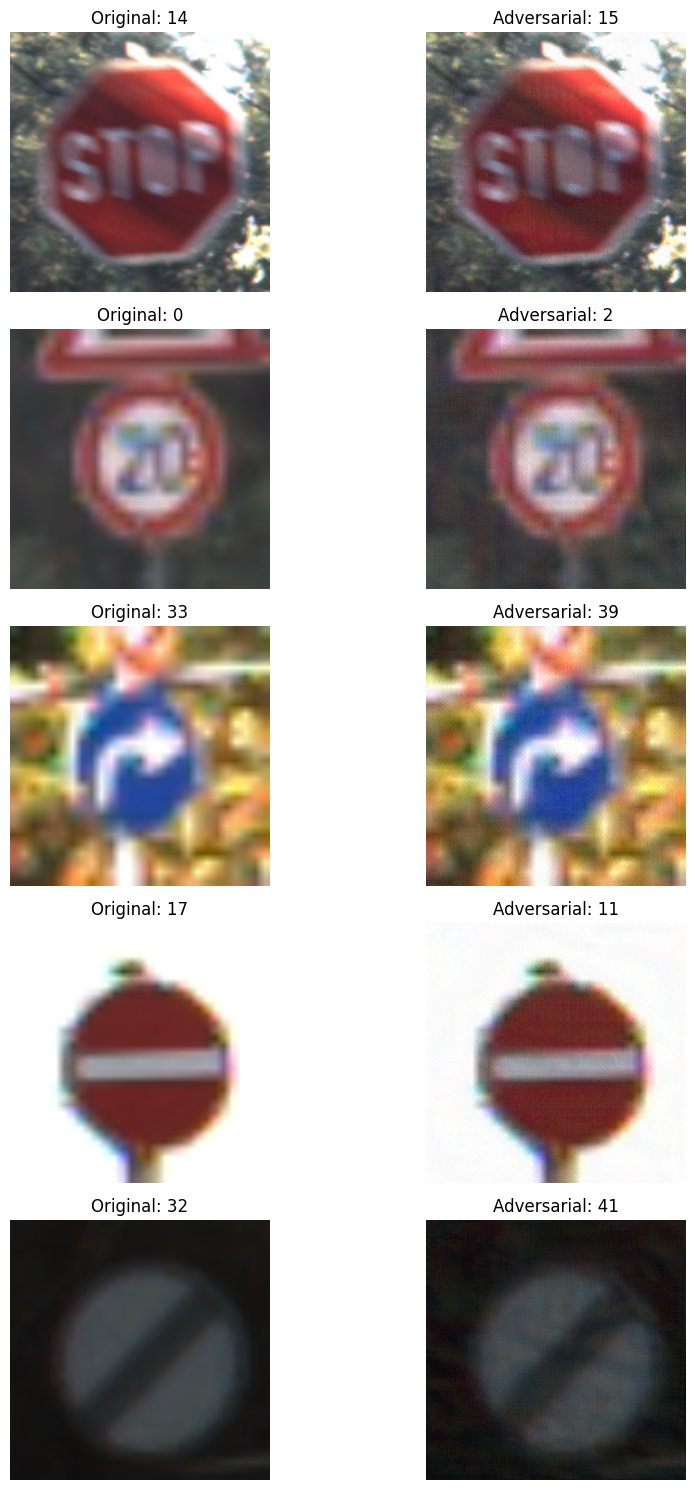

In [112]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# Randomly select 5 indices from the adversarial examples
indices = random.sample(range(len(adv_images)), 5)

# Prepare the plot
fig, axes = plt.subplots(5, 2, figsize=(10, 15))

for i, idx in enumerate(indices):
    # Get the original image and its adversarial version
    original_img = tf.io.read_file(os.path.join(new_directory_path, image_filenames[idx]))
    original_img = tf.image.decode_png(original_img, channels=3)
    original_img = tf.image.resize(original_img, [img_height, img_width])
    original_img = tf.cast(original_img, tf.float32)

    # Adversarial image (already stored in adv_images)
    adv_img = adv_images[idx]

    # Predict the class of both original and adversarial images
    original_pred = model.predict(tf.expand_dims(original_img, 0))
    adv_pred = model.predict(tf.expand_dims(adv_img, 0))

    original_class = tf.argmax(original_pred, axis=1).numpy()[0]
    adv_class = tf.argmax(adv_pred, axis=1).numpy()[0]

    # Plot original image with its prediction
    axes[i, 0].imshow(original_img / 255.0)  # Normalize for display
    axes[i, 0].set_title(f"Original: {original_class}")
    axes[i, 0].axis('off')

    # Plot adversarial image with its prediction
    axes[i, 1].imshow(adv_img / 255.0)  # Normalize for display
    axes[i, 1].set_title(f"Adversarial: {adv_class}")
    axes[i, 1].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()
